# **Business Case 1: Segmenting Clients - Insurance**

This Section is specifically dedicated at finding the clusters that best describe the personas to whom to sell insurance. 


In [246]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import prince
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [247]:
# Load data in a DataFrame
path = "./Dataset1_BankClients.xlsx"
data = pd.read_excel(path)

In [248]:
# Drop the column ID
data = data.drop(columns=['ID']) 
data.head()

,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,24,1,1,2,2,4,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,0.283222,1
1,47,1,2,2,3,1,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,0.821590,3
2,38,0,2,1,2,2,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,0.503790,3
3,67,0,2,1,2,3,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,0.691240,2
4,33,0,2,1,3,1,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,0.615916,2


## Outlier Analysis

In [249]:
def find_outliers_selective(df, columns_to_check):
    """
    df: Your pandas DataFrame
    columns_to_check: List of strings (names of continuous numerical columns)
    """
    rows_to_drop = set()
    
    for col in columns_to_check:
        data = df[col].values
        mean, std = data.mean(), data.std()
        
        # 3-sigma rule
        lower, upper = mean - 3*std, mean + 3*std
        
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        
        if not outliers.empty:
            print(f"Feature '{col}' has {len(outliers)} outliers.")
            rows_to_drop.update(outliers.index.tolist())
            
    # Drop rows by index
    df_cleaned = df.drop(index=list(rows_to_drop))
    print(f"\nDropped {len(rows_to_drop)} total rows.")
    return df_cleaned

# Usage: Only pass Age or Family Members, NOT Gender/Occupation/Percentiles
categorical_cols = ['Gender', 'Job', 'Area', 'CitySize', 'Investments']
continuous_cols =  [col for col in data.columns if col not in categorical_cols]
data = find_outliers_selective(data, continuous_cols)

Feature 'ESG' has 5 outliers.
Feature 'BankFriend' has 2 outliers.

Dropped 7 total rows.


# Setup for Insurance

For the insurance clusters, the datas that do make sense to include, when used in a "raw" state return only around 37% of variance explained with FAMD which isn't optimal to draw conclusions from. We therefore decided to implement ratios instead of variables that are qualitatively correlated (might not show up in the dataset but would make sense for them to be) and create ratios.

In [250]:
# Create the ratios and add an infinitesimal amount to avoid errors from the div by 0
data['Debt_to_Income'] = data['Debt'] / (data['Income'] + 0.0001) 
data['Safety_Net'] = (data['Wealth'] + data['Saving']) / (data['Income'] + 0.0001)
data['Dependents_Risk'] = data['FamilySize'] / data['Age']
data['Asset_Exposure'] = data['Luxury'] / (data['Income'] + 0.0001)

# Re-trim the dataset from outliers
data['Debt_to_Income'] = data['Debt_to_Income'].clip(upper=5)
data['Safety_Net'] = data['Safety_Net'].clip(upper=5)
data['Dependents_Risk'] = data['Dependents_Risk'].clip(upper=5)
data['Asset_Exposure'] = data['Asset_Exposure'].clip(upper=5)

# We define the "risk engine"
active_risk_cols = [
    'Debt_to_Income', 
    'Safety_Net', 
    'Dependents_Risk', 
    'Asset_Exposure', 
    'FinEdu', 
    'Job'
]
df_active_mixed = data[active_risk_cols].copy()

# Initialize and Fit FAMD
famd = prince.FAMD(
    n_components=3, #dims to reduce to
    n_iter=10, #coordinate optimization max iter
    copy=True,
    check_input=True,
    engine='sklearn', #lib
    random_state=42 #seed
)

# Transform the mixed data into pure continuous coordinates
X_famd = famd.fit_transform(df_active_mixed)
X_famd.columns = ['Dim_1', 'Dim_2', 'Dim_3']

print("\nFAMD Continuous Coordinates (Ready for Clustering):")
display(X_famd.head(3))

#  Check the Variance Explained
explained_variance = famd.percentage_of_variance_

# The newer library outputs actual percentages (e.g., 45.2 instead of 0.452)
# We do a quick check to see if we need to multiply by 100
total_var = sum(explained_variance)
if total_var <= 1.0:
    total_var *= 100
    explained_variance = [v * 100 for v in explained_variance]

print(f"\nTotal Variance Explained by 3 Dimensions: {total_var:.2f}%")


FAMD Continuous Coordinates (Ready for Clustering):


,Dim_1,Dim_2,Dim_3
0,-0.193926,2.103062,2.013974
1,0.193765,1.283705,-1.556866
2,-0.772939,0.208092,0.129753



Total Variance Explained by 3 Dimensions: 61.12%


Silhouette Score for k=4: 0.339


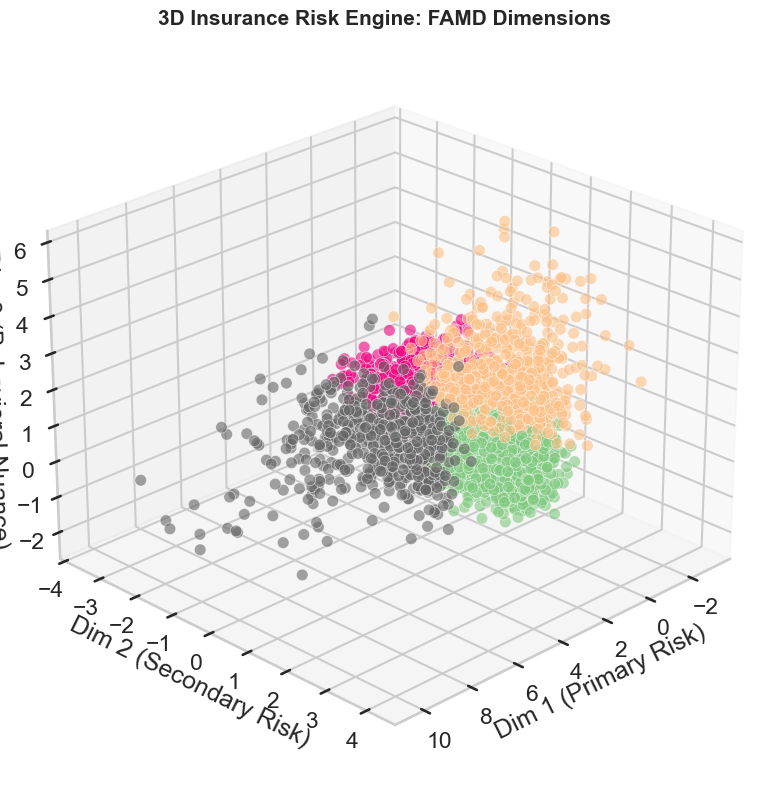


--- CLUSTER PROFILES (The Business Truth) ---


,Wealth,Income,Debt,Saving,FamilySize,Job,Debt_to_Income,Safety_Net,Dependents_Risk,Asset_Exposure,FinEdu
Cluster_ID,,,,,,,,,,,
0,0.66,0.69,0.53,0.58,1,2,0.81,1.89,0.04,0.87,0.65
1,0.57,0.60,0.47,0.53,4,2,0.85,1.96,0.13,0.81,0.48
2,0.47,0.52,0.26,0.43,1,5,0.51,1.87,0.03,0.66,0.34
3,0.57,0.28,0.46,0.54,1,2,1.72,3.98,0.05,1.80,0.46


In [ ]:
import matplotlib.pyplot as plt

# We set k=4 from the later scores that we in the next part as it is optimal for this one
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42) #Since we used FAMD we can use k_means which is faster and more accurate!
cluster_labels = kmeans.fit_predict(X_famd)

sil_score = silhouette_score(X_famd, cluster_labels)
print(f"Silhouette Score for k={optimal_k}: {sil_score:.3f}")

# 1. Create the 3D figure
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# 2. Plot using your existing FAMD Dimensions
# We use 'c' for color and 'cmap' for the palette
scatter = ax.scatter(
    X_famd['Dim_1'], 
    X_famd['Dim_2'], 
    X_famd['Dim_3'],
    c=cluster_labels, 
    cmap='Accent',    
    s=70,             # Point size
    alpha=0.6,        # Transparency to see through clusters
    edgecolor='w',    # White border for better definition
    linewidth=0.5
)

# 3. Labeling and Aesthetics
ax.set_title('3D Insurance Risk Engine: FAMD Dimensions', fontsize=15, fontweight='bold')
ax.set_xlabel('Dim 1 (Primary Risk)')
ax.set_ylabel('Dim 2 (Secondary Risk)')
ax.set_zlabel('Dim 3 (Behavioral Nuance)')

# 1. Position the legend OUTSIDE the 3D box but INSIDE the figure
# (1.05, 1) means: 5% past the right edge, aligned with the top
legend = ax.legend(*scatter.legend_elements(), title="Clusters", 
                   loc="upper left", bbox_to_anchor=(1.05, 1))
ax.add_artist(legend)

# 2. Set your viewing angle
ax.view_init(elev=25, azim=45)

# 3. Final layout: Use ONE of these, not both. 
# subplots_adjust is better for 3D because it's manual and precise.
plt.subplots_adjust(right=0.85, top=0.9, bottom=0.1, left=0.7)

plt.show()

# 6. Profile the Clusters to find the Business Target
# Map clusters back to the ORIGINAL data frame to see raw numbers
data['Cluster_ID'] = cluster_labels

print("\n--- CLUSTER PROFILES (The Business Truth) ---")
display(data.groupby('Cluster_ID').agg({
    # Raw stats
    'Wealth': 'mean',
    'Income': 'mean',
    'Debt': 'mean',
    'Saving': 'mean',
    'FamilySize': lambda x: x.mode()[0],
    'Job': lambda x: x.mode()[0],
    
    # NEW: Your Engineered Risk Engine!
    'Debt_to_Income': 'mean',
    'Safety_Net': 'mean',
    'Dependents_Risk': 'mean',
    'Asset_Exposure': 'mean',
    'FinEdu': 'mean' 
}).round(2))

Evaluating clusters in FAMD space...


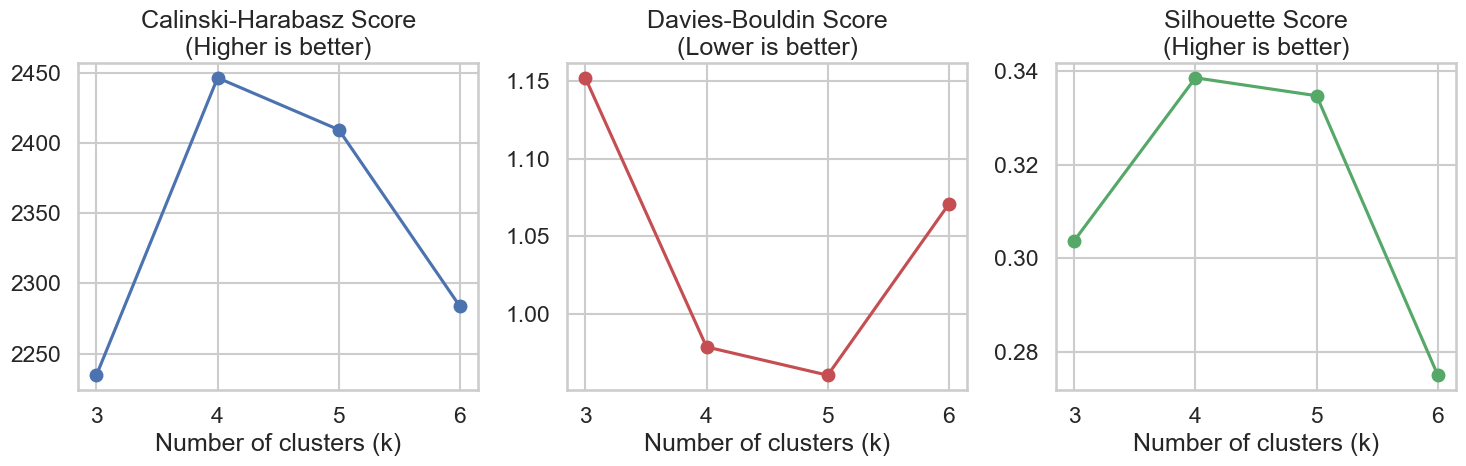

Optimal k according to Calinski-Harabasz (Max): 4
Optimal k according to Davies-Bouldin (Min): 5
Optimal k according to Silhouette (Max): 4


In [252]:
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Define the range of k values you want to test
k_values = range(3, 7)

# Initialize lists to store the metrics
ch_scores = []
db_scores = []
sil_scores = []
cluster_results = {}

# Calculate metrics for each k
print("Evaluating clusters in FAMD space...")
for k in k_values:
    # Run K-means on the FAMD data
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_famd)
    cluster_results[k] = labels
    
    # Calculate and store the three scores
    ch_scores.append(calinski_harabasz_score(X_famd, labels))
    db_scores.append(davies_bouldin_score(X_famd, labels))
    sil_scores.append(silhouette_score(X_famd, labels))

# Plot evaluation metrics
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Calinski-Harabasz (Higher is better)
ax1.plot(k_values, ch_scores, 'bo-')
ax1.set_title('Calinski-Harabasz Score\n(Higher is better)')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_xticks(k_values)
ax1.grid(True)

# Davies-Bouldin (Lower is better)
ax2.plot(k_values, db_scores, 'ro-')
ax2.set_title('Davies-Bouldin Score\n(Lower is better)')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_xticks(k_values)
ax2.grid(True)

# Silhouette (Higher is better)
ax3.plot(k_values, sil_scores, 'go-')
ax3.set_title('Silhouette Score\n(Higher is better)')
ax3.set_xlabel('Number of clusters (k)')
ax3.set_xticks(k_values)
ax3.grid(True)

plt.tight_layout()
plt.show()

# Print optimal values automatically
best_ch_k = k_values[np.argmax(ch_scores)]
best_db_k = k_values[np.argmin(db_scores)]
best_sil_k = k_values[np.argmax(sil_scores)]

print(f"Optimal k according to Calinski-Harabasz (Max): {best_ch_k}")
print(f"Optimal k according to Davies-Bouldin (Min): {best_db_k}")
print(f"Optimal k according to Silhouette (Max): {best_sil_k}")

In [253]:
# 1. Extract the column contributions to each FAMD dimension
contributions = famd.column_contributions_.style.format("{:.2%}")
print("--- FEATURE CONTRIBUTIONS TO FAMD DIMENSIONS ---")
display(contributions)

# Extract the raw numbers from the Styler object
raw_contributions = contributions.data

# Now perform the math on the raw dataframe to force it to 100%
normalized_contributions = (raw_contributions.div(raw_contributions.sum(axis=0), axis=1)) * 100

print("--- NORMALIZED FEATURE CONTRIBUTIONS ---")
display(normalized_contributions.round(2).astype(str) + '%')


# 2. Extract column correlations (for continuous variables)
# This tells you the direction (positive/negative correlation)
try:
    # 1. Get the FAMD coordinates (the components/scores)
    row_coordinates = famd.transform(df_active_mixed)

    # 2. Identify your numerical columns
    # (FAMD correlations are typically only meaningful for continuous data)
    numerical_cols = df_active_mixed.select_dtypes(include=['number']).columns

    # 3. Calculate correlation between original numerical data and FAMD dimensions
    correlations = df_active_mixed[numerical_cols].apply(lambda x: row_coordinates.corrwith(x))

    print("\n--- FEATURE CORRELATIONS WITH DIMENSIONS (MANUAL) ---")
    display(correlations.round(3))
except AttributeError:
    pass # Older versions of Prince might handle this differently


--- FEATURE CONTRIBUTIONS TO FAMD DIMENSIONS ---


component,0,1,2
variable,,,
Debt_to_Income,32.90%,1.44%,0.00%
Safety_Net,33.84%,5.82%,0.02%
Dependents_Risk,0.64%,20.04%,71.45%
Asset_Exposure,31.56%,0.33%,0.95%
FinEdu,0.18%,56.37%,24.85%
Job,1.76%,32.00%,5.44%


--- NORMALIZED FEATURE CONTRIBUTIONS ---


component,0,1,2
variable,,,
Debt_to_Income,32.62%,1.24%,0.0%
Safety_Net,33.55%,5.02%,0.02%
Dependents_Risk,0.63%,17.28%,69.56%
Asset_Exposure,31.28%,0.28%,0.93%
FinEdu,0.17%,48.6%,24.19%
Job,1.75%,27.58%,5.3%



--- FEATURE CORRELATIONS WITH DIMENSIONS (MANUAL) ---


,Debt_to_Income,Safety_Net,Dependents_Risk,Asset_Exposure,FinEdu,Job
component,,,,,,
0,0.829,0.841,0.115,0.812,0.061,-0.114
1,0.131,-0.264,0.489,-0.062,0.821,-0.477
2,0.007,0.015,0.842,-0.097,-0.497,-0.106


In [254]:
# Map the clusters back to the ORIGINAL dataframe
data['Cluster_ID'] = cluster_labels

print("--- THE FINANCIAL PERSONAS (Averages by Cluster) ---")
profile_active = data.groupby('Cluster_ID').agg({
    # Raw stats
    'Wealth': 'mean',
    'Income': 'mean',
    'Debt': 'mean',
    'Saving': 'mean',
    'FamilySize': lambda x: x.mode()[0],
    'Job': lambda x: x.mode()[0],
    
    # NEW: Add the engineered ratios here so the dashboard can see them!
    'Debt_to_Income': 'mean',
    'Safety_Net': 'mean',
    'Dependents_Risk': 'mean',
    'Asset_Exposure': 'mean',
    'FinEdu': 'mean' 
}).round(2)

display(profile_active)

--- THE FINANCIAL PERSONAS (Averages by Cluster) ---


,Wealth,Income,Debt,Saving,FamilySize,Job,Debt_to_Income,Safety_Net,Dependents_Risk,Asset_Exposure,FinEdu
Cluster_ID,,,,,,,,,,,
0,0.66,0.69,0.53,0.58,1,2,0.81,1.89,0.04,0.87,0.65
1,0.57,0.60,0.47,0.53,4,2,0.85,1.96,0.13,0.81,0.48
2,0.47,0.52,0.26,0.43,1,5,0.51,1.87,0.03,0.66,0.34
3,0.57,0.28,0.46,0.54,1,2,1.72,3.98,0.05,1.80,0.46


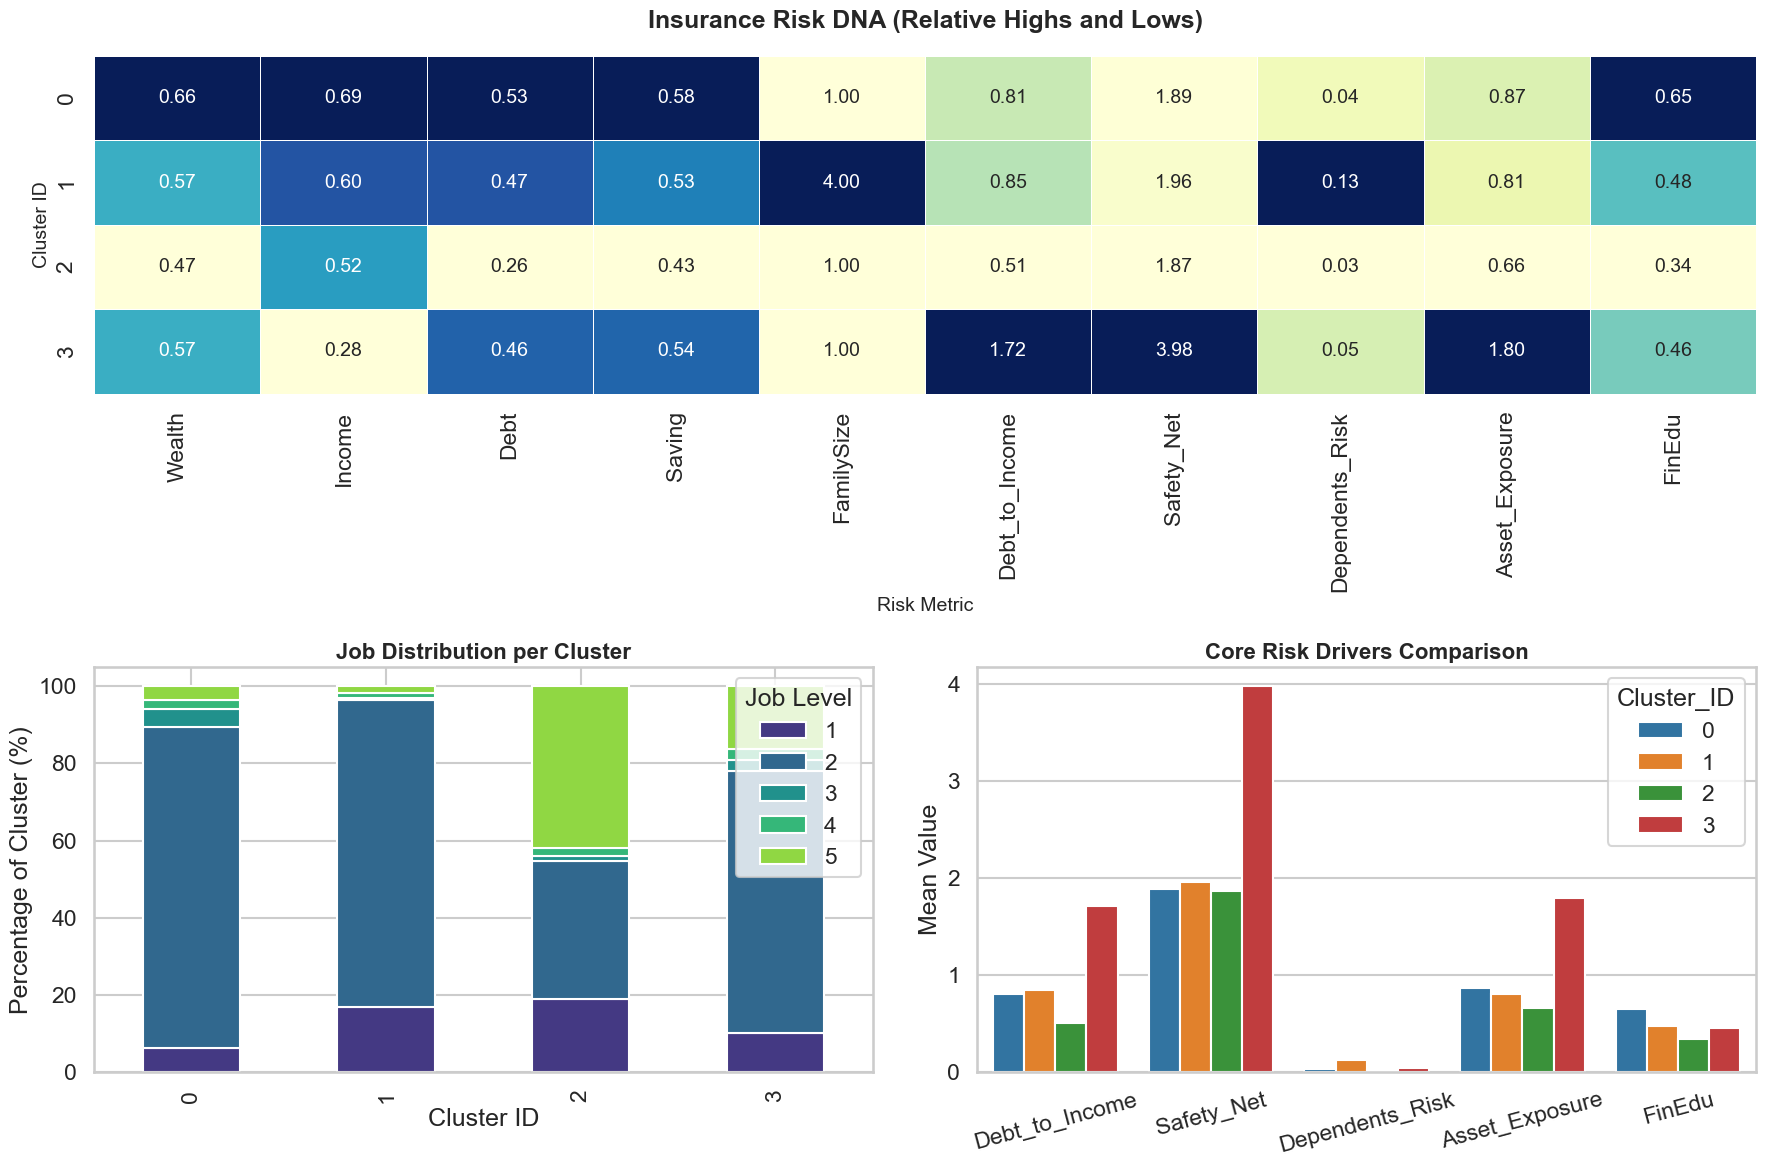

In [255]:
# 1. Prepare the Data
# We exclude 'Job' for the heatmap because it's categorical
num_profile = profile_active.drop(columns=['Job'])

# Scale the means (0 to 1) just for the heatmap colors to ensure 
# high values are dark and low values are light across different scales.
scaler = MinMaxScaler()
scaled_profile = pd.DataFrame(
    scaler.fit_transform(num_profile), 
    columns=num_profile.columns, 
    index=num_profile.index
)

# ==========================================
# INSURANCE RISK PERSONA DASHBOARD
# ==========================================
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

# A. THE HEATMAP (The "Pattern" View)
ax0 = fig.add_subplot(gs[0, :])
sns.heatmap(scaled_profile, annot=num_profile, fmt=".2f", cmap="YlGnBu", 
            cbar=False, linewidths=.5, ax=ax0, annot_kws={"size": 14})
ax0.set_title("Insurance Risk DNA (Relative Highs and Lows)", fontsize=18, fontweight='bold', pad=20)
ax0.set_xlabel("Risk Metric", fontsize=14)
ax0.set_ylabel("Cluster ID", fontsize=14)

# B. THE CATEGORICAL TARGET (Job Level)
ax1 = fig.add_subplot(gs[1, 0])
# We look at the actual distribution of Jobs for each cluster
inv_dist = pd.crosstab(data['Cluster_ID'], data['Job'], normalize='index') * 100
inv_dist.plot(kind='bar', stacked=True, ax=ax1, color=sns.color_palette("viridis", 5))
ax1.set_title("Job Distribution per Cluster", fontsize=16, fontweight='bold')
ax1.set_ylabel("Percentage of Cluster (%)")
ax1.set_xlabel("Cluster ID")
ax1.legend(title="Job Level", loc='upper right')

# C. THE COMPARISON (New Risk Ratios)
ax2 = fig.add_subplot(gs[1, 1])
# Melting for a grouped bar chart using our NEW engineered columns
new_risk_cols = ['Debt_to_Income', 'Safety_Net', 'Dependents_Risk', 'Asset_Exposure', 'FinEdu']
melted_active = num_profile[new_risk_cols].reset_index().melt(id_vars='Cluster_ID')

sns.barplot(data=melted_active, x='variable', y='value', hue='Cluster_ID', ax=ax2, palette='tab10')
ax2.set_title("Core Risk Drivers Comparison", fontsize=16, fontweight='bold')
ax2.set_ylabel("Mean Value")
ax2.set_xlabel("")
ax2.tick_params(axis='x', rotation=15) # Slightly rotate labels since they are longer now

plt.tight_layout()
plt.show()

In [256]:
# Merge the cluster labels onto your quarantined demographic/psychographic data
df_passive_obj1 = data.drop(columns=active_risk_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster (replace '2' with whatever ID you found in Step 2)
target_cluster_id = 0
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# 1. Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Area', 'CitySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# 2. Numerical Distributions (Age, Digital, BankFriend, FinEdu)
# Using .describe() gives you the mean, min, max, and quartiles
num_cols = ['Age', 'Digital', 'BankFriend']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])



# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Isolate your target cluster
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

--- MARKETING PROFILE FOR TARGET CLUSTER 0 ---
Average Age: 57.7
Most common Gender: 0
Digital Propensity: 0.63
BankFriend Propensity: 0.65
Most common Area: 1
Most common CitySize: 3
--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 0 ---

--- Gender Distribution ---
Gender
0    50.6%
1    49.4%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    76.2%
2    13.5%
3    10.4%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
3    39.3%
2    36.0%
1    24.7%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend
mean  57.655812  0.631033    0.653995
min   19.000000  0.060530    0.158130
50%   56.000000  0.646948    0.669520
max   95.000000  0.960109    0.974230
--- VOLUME SUMMARY FOR CLUSTER 0 ---
Total People in Cluster: 2211
Percentage of Total Base: 44.3%
----------------------------------------


/var/folders/lh/rz4q26c96072y2l855h8155m0000gn/T/ipykernel_49516/852564969.py:37: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




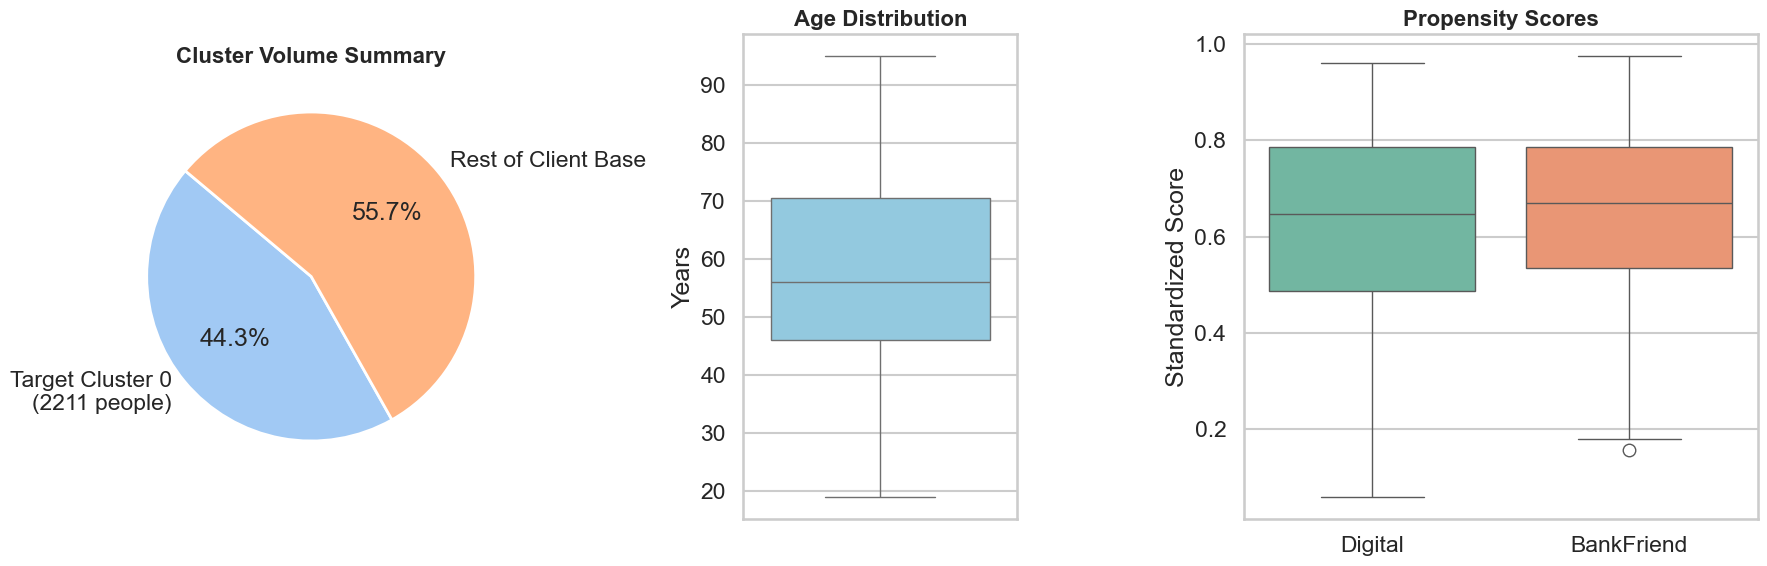

/var/folders/lh/rz4q26c96072y2l855h8155m0000gn/T/ipykernel_49516/852564969.py:60: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/var/folders/lh/rz4q26c96072y2l855h8155m0000gn/T/ipykernel_49516/852564969.py:60: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/var/folders/lh/rz4q26c96072y2l855h8155m0000gn/T/ipykernel_49516/852564969.py:60: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/var/folders/lh/rz4q26c96072y2l855h8155m0000gn/T/ipykernel_49516/852564969.py:60: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the 

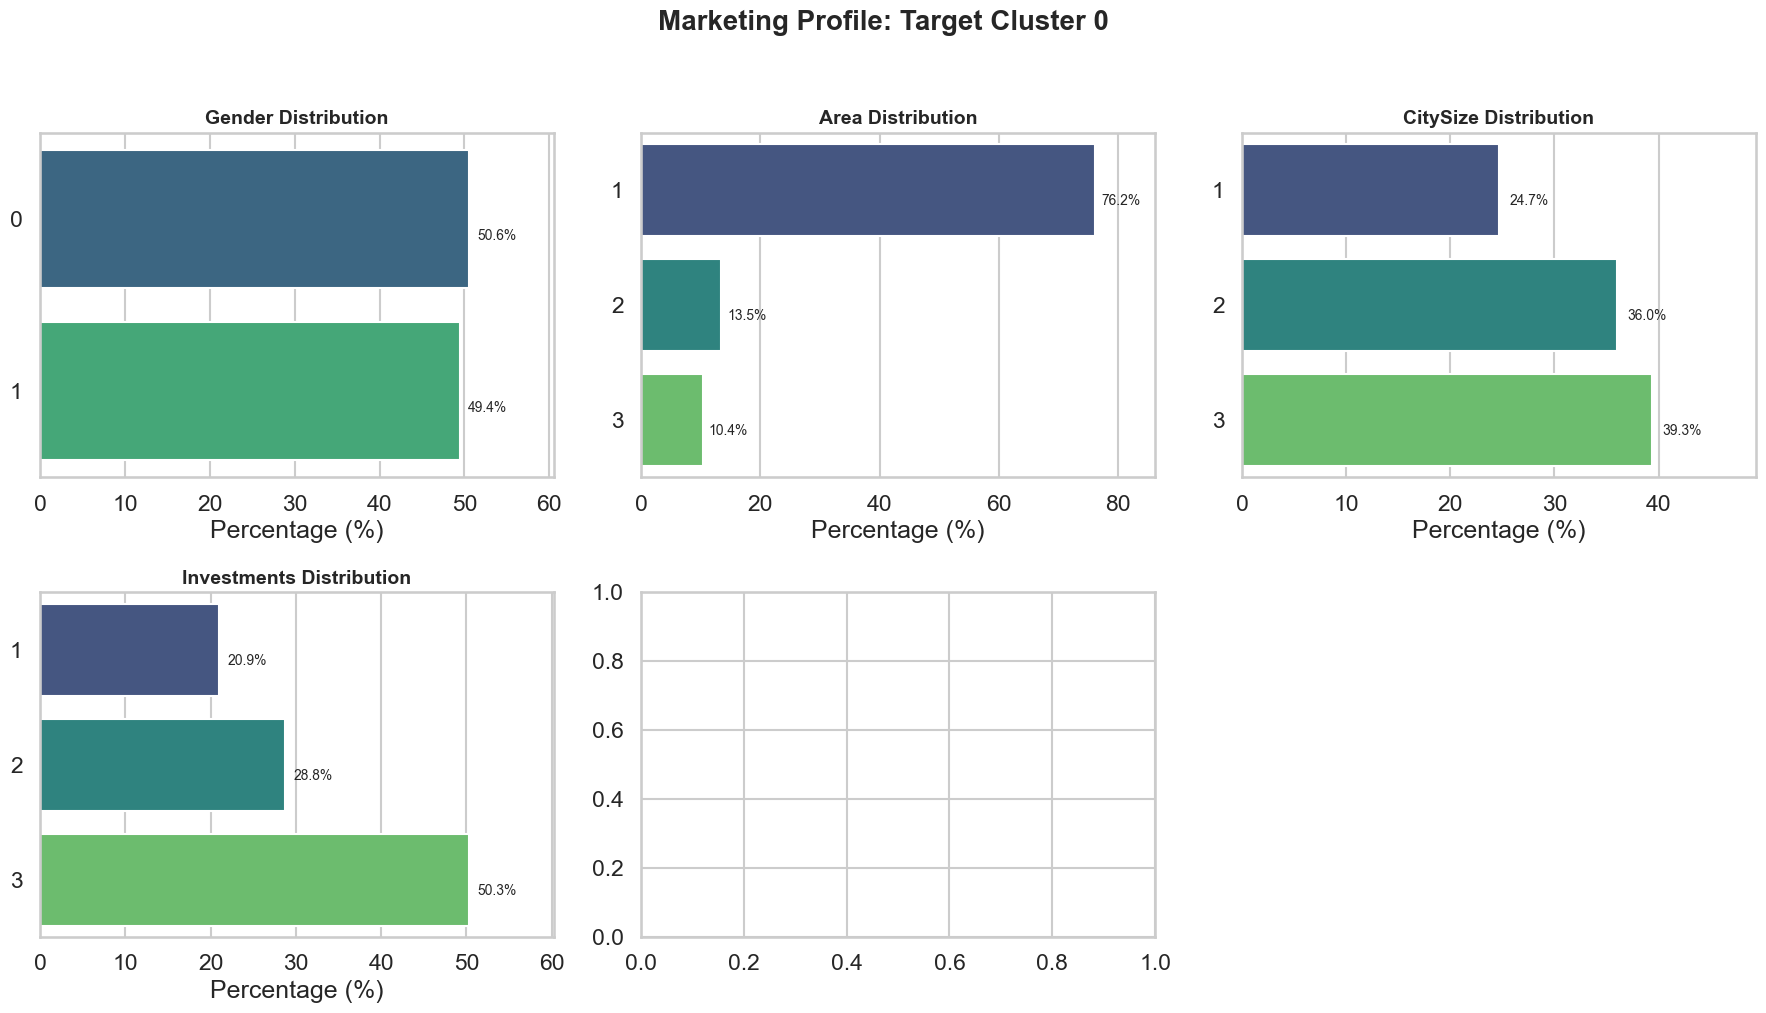

In [257]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set the visual style for the dashboard
sns.set_theme(style="whitegrid", context="talk")

# --- Setup Variables ---
# (Assuming target_cluster_id and target_profile are already defined)
total_count = len(df_passive_obj1)
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

# ==========================================
# DASHBOARD PART 1: VOLUME & NUMERICAL TRAITS
# ==========================================
# We changed this to 3 columns: Pie Chart, Age Plot, Propensity Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [1.2, 0.8, 1.5]})

# 1A. Pie Chart for Volume
labels = [f'Target Cluster {target_cluster_id}\n({cluster_count} people)', 'Rest of Client Base']
sizes = [cluster_count, total_count - cluster_count]
colors = sns.color_palette('pastel')[0:2]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, 
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title(f"Cluster Volume Summary", fontsize=16, fontweight='bold')

# 1B. Boxplot strictly for AGE
sns.boxplot(data=target_profile, y='Age', ax=axes[1], color='skyblue')
axes[1].set_title("Age Distribution", fontsize=16, fontweight='bold')
axes[1].set_ylabel("Years")

# 1C. Boxplots strictly for STANDARDIZED SCORES
scaled_cols = ['Digital', 'BankFriend']
melted_scaled = target_profile[scaled_cols].melt(var_name='Feature', value_name='Score')

sns.boxplot(data=melted_scaled, x='Feature', y='Score', ax=axes[2], palette='Set2')
axes[2].set_title("Propensity Scores", fontsize=16, fontweight='bold')
axes[2].set_xlabel("")
axes[2].set_ylabel("Standardized Score")

plt.tight_layout()
plt.show()


# ==========================================
# DASHBOARD PART 2: CATEGORICAL DISTRIBUTIONS
# ==========================================
cat_cols = ['Gender', 'Area', 'CitySize','Investments']

# Create a grid of subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Flatten to easily loop through them

for i, col in enumerate(cat_cols):
    # Calculate percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    
    # Create Horizontal Bar Plot
    sns.barplot(x=dist.values, y=dist.index, ax=axes[i], palette='viridis', orient='h')
    
    # Formatting
    axes[i].set_title(f"{col} Distribution", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Percentage (%)")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0, max(dist.values) + 10) # Give a little breathing room on the right
    
    # Add exact percentage text labels onto the bars
    for p in axes[i].patches:
        width = p.get_width()
        axes[i].text(width + 1, p.get_y() + p.get_height()/2. + 0.1, 
                     f'{width:.1f}%', ha="left", va="center", fontsize=10)

# Hide the 6th empty subplot (since we only have 5 categorical columns)
axes[5].axis('off')

fig.suptitle(f"Marketing Profile: Target Cluster {target_cluster_id}", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [258]:
# Merge the cluster labels onto your quarantined demographic/psychographic data
df_passive_obj1 = data.drop(columns=active_risk_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster (replace '2' with whatever ID you found in Step 2)
target_cluster_id = 1
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# 1. Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Area', 'CitySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# 2. Numerical Distributions (Age, Digital, BankFriend, FinEdu)
# Using .describe() gives you the mean, min, max, and quartiles
num_cols = ['Age', 'Digital', 'BankFriend']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])



# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Isolate your target cluster
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

--- MARKETING PROFILE FOR TARGET CLUSTER 1 ---
Average Age: 34.8
Most common Gender: 1
Digital Propensity: 0.55
BankFriend Propensity: 0.59
Most common Area: 1
Most common CitySize: 2
--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 1 ---

--- Gender Distribution ---
Gender
1    50.9%
0    49.1%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    69.4%
2    16.0%
3    14.5%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
2    46.7%
1    36.7%
3    16.5%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend
mean  34.774624  0.547874    0.591183
min   19.000000  0.000000    0.208111
50%   31.000000  0.544724    0.595606
max   93.000000  0.971778    0.961477
--- VOLUME SUMMARY FOR CLUSTER 1 ---
Total People in Cluster: 599
Percentage of Total Base: 12.0%
----------------------------------------


In [259]:
# Merge the cluster labels onto your quarantined demographic/psychographic data
df_passive_obj1 = data.drop(columns=active_risk_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster (replace '2' with whatever ID you found in Step 2)
target_cluster_id = 2
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# 1. Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Area', 'CitySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# 2. Numerical Distributions (Age, Digital, BankFriend, FinEdu)
# Using .describe() gives you the mean, min, max, and quartiles
num_cols = ['Age', 'Digital', 'BankFriend']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])



# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Isolate your target cluster
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

--- MARKETING PROFILE FOR TARGET CLUSTER 2 ---
Average Age: 73.1
Most common Gender: 1
Digital Propensity: 0.39
BankFriend Propensity: 0.60
Most common Area: 1
Most common CitySize: 2
--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 2 ---

--- Gender Distribution ---
Gender
1    57.7%
0    42.3%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    68.3%
2    21.4%
3    10.3%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
2    46.1%
1    40.0%
3    13.8%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend
mean  73.104803  0.393510    0.603109
min   19.000000  0.000000    0.166759
50%   77.000000  0.379370    0.608427
max   95.000000  0.969335    0.972129
--- VOLUME SUMMARY FOR CLUSTER 2 ---
Total People in Cluster: 1603
Percentage of Total Base: 32.1%
----------------------------------------


In [260]:
# Merge the cluster labels onto your quarantined demographic/psychographic data
df_passive_obj1 = data.drop(columns=active_risk_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster (replace '2' with whatever ID you found in Step 2)
target_cluster_id = 0
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# 1. Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Area', 'CitySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# 2. Numerical Distributions (Age, Digital, BankFriend, FinEdu)
# Using .describe() gives you the mean, min, max, and quartiles
num_cols = ['Age', 'Digital', 'BankFriend']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])



# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Isolate your target cluster
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

--- MARKETING PROFILE FOR TARGET CLUSTER 0 ---
Average Age: 57.7
Most common Gender: 0
Digital Propensity: 0.63
BankFriend Propensity: 0.65
Most common Area: 1
Most common CitySize: 3
--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 0 ---

--- Gender Distribution ---
Gender
0    50.6%
1    49.4%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    76.2%
2    13.5%
3    10.4%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
3    39.3%
2    36.0%
1    24.7%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend
mean  57.655812  0.631033    0.653995
min   19.000000  0.060530    0.158130
50%   56.000000  0.646948    0.669520
max   95.000000  0.960109    0.974230
--- VOLUME SUMMARY FOR CLUSTER 0 ---
Total People in Cluster: 2211
Percentage of Total Base: 44.3%
----------------------------------------


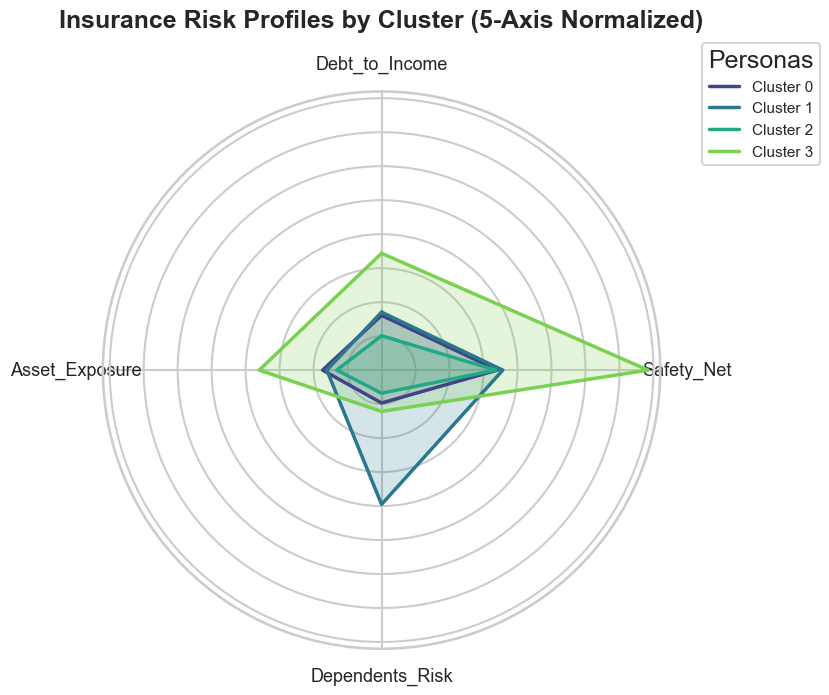

In [261]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_insurance_cluster_radar(data):
    # 1. Define ALL 5 numerical features for the radar
    radar_features = ['Debt_to_Income', 'Safety_Net', 'Dependents_Risk', 'Asset_Exposure']
    
    # Create a copy of the data with just our target columns
    plot_data = data[['Cluster_ID'] + radar_features].copy()

    # 2. Normalize all numerical variables (0 to 1 scale) so they share the same axis
    scaler = MinMaxScaler()
    plot_data[radar_features] = scaler.fit_transform(plot_data[radar_features])

    # 3. Calculate mean values for each numerical variable by cluster
    cluster_means = plot_data.groupby('Cluster_ID')[radar_features].mean()

    # Set up the radar chart mathematics (now a pentagon instead of a square)
    categories = radar_features
    num_vars = len(categories)
    angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
    angles += angles[:1] # Close the loop

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(projection='polar'))
    
    # Use the same 'viridis' color palette from your earlier scatterplots
    colors = sns.color_palette("viridis", len(cluster_means))

    # 4. Plot for each cluster dynamically
    for i, (cluster_id, row) in enumerate(cluster_means.iterrows()):
        values = row.values.flatten().tolist()
        values += values[:1] # Close the loop
        
        ax.plot(angles, values, linewidth=2.5, linestyle='solid', label=f'Cluster {cluster_id}', color=colors[i])
        ax.fill(angles, values, alpha=0.2, color=colors[i])

    # Set chart properties for a clean look
    ax.set_theta_offset(np.pi / 2) # Start at the top
    ax.set_theta_direction(-1)     # Go clockwise
    
    # Add category labels and hide the messy radial numbers
    plt.xticks(angles[:-1], categories, fontsize=13)
    ax.set_yticklabels([]) 
    
    plt.title("Insurance Risk Profiles by Cluster (5-Axis Normalized)", size=18, fontweight='bold', y=1.1)
    
    # Move the legend outside the chart so it doesn't overlap the data
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), title="Personas", fontsize=11)

    plt.tight_layout()
    plt.show()

# Run the function!
plot_insurance_cluster_radar(data)

In [262]:
print(data.columns.tolist())

['Age', 'Gender', 'Job', 'Area', 'CitySize', 'FamilySize', 'Income', 'Wealth', 'Debt', 'FinEdu', 'ESG', 'Digital', 'BankFriend', 'LifeStyle', 'Luxury', 'Saving', 'Investments', 'Debt_to_Income', 'Safety_Net', 'Dependents_Risk', 'Asset_Exposure', 'Cluster_ID']
